# Running Palace Simulations: Branch Line Coupler

[Palace](https://awslabs.github.io/palace/) is an open-source 3D electromagnetic simulator supporting eigenmode, driven (S-parameter), and electrostatic simulations. This notebook demonstrates using the `gsim.palace` API to run a driven simulation on a branch line coupler.

**Requirements:**

- IHP PDK: `uv pip install ihp-gdsfactory`
- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

### Load a pcell from IHP PDK

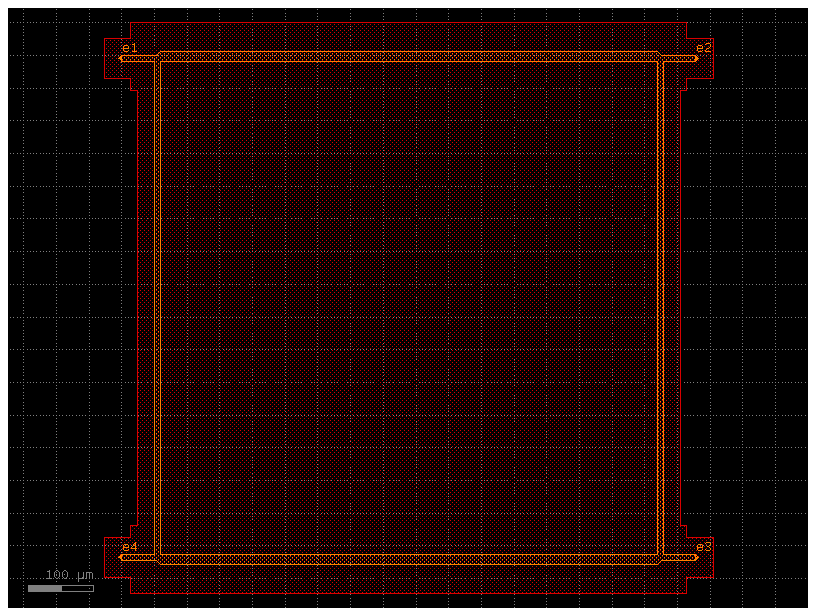

In [1]:
import gdsfactory as gf
from ihp import LAYER, PDK, cells

PDK.activate()

c = gf.Component()
r1 = c << cells.branch_line_coupler(
    width=8.85, width_coupled=14.96, quarter_wave_length=769.235, connection_length=50
)
c.add_ports(r1.ports)

# Save port info before flatten
ports = [(p.name, p.center, p.width, p.orientation, p.layer) for p in c.ports]

c.flatten()

# Fill holes in Metal3 ground plane
r = c.get_region(layer=LAYER.Metal3drawing)
r_filled = gf.kdb.Region([gf.kdb.Polygon(list(p.each_point_hull())) for p in r.each()])
c.remove_layers(layers=[LAYER.Metal3drawing])
c.add_polygon(r_filled, layer=LAYER.Metal3drawing)

# Re-add ports
for name, center, width, orientation, layer in ports:
    c.add_port(
        name=name, center=center, width=width, orientation=orientation, layer=layer
    )

cc = c.copy()
cc.draw_ports()
cc

### Configure and run simulation with DrivenSim

In [2]:
from gsim.palace import DrivenSim

# Create simulation object
sim = DrivenSim()

# Set output directory
sim.set_output_dir("./palace-sim-branch-coupler")

# Set the component geometry
sim.set_geometry(c)

# Configure layer stack from active PDK
sim.set_stack(substrate_thickness=2.0, air_above=300.0)

# Configure via ports (Metal3 ground plane to TopMetal2 signal)
for port in c.ports:
    sim.add_port(port.name, from_layer="metal3", to_layer="topmetal2", geometry="via")

# Configure driven simulation (frequency sweep for S-parameters)
sim.set_driven(fmin=1e9, fmax=100e9, num_points=300)

# Validate configuration
print(sim.validate_config())

Validation: PASSED


In [3]:
# Generate mesh (presets: "coarse", "default", "fine")
sim.mesh(preset="default")

Mesh Summary
Dimensions: 1031.2 x 974.0 x 318.3 µm
Nodes:      18,524
Elements:   141,736
Tetrahedra: 102,278
Edge length: 0.40 - 351.31 µm
Quality:    0.415 (min: 0.000)
SICN:       0.456 (all valid)
----------------------------------------
Volumes (3):
  - SiO2 [1]
  - passive [2]
  - air [3]
Surfaces (13):
  - metal3_xy [4]
  - metal3_z [5]
  - topmetal2_xy [6]
  - topmetal2_z [7]
  - P1 [8]
  - P2 [9]
  - P3 [10]
  - P4 [11]
  - SiO2__None [12]
  - SiO2__passive [13]
  - passive__None [14]
  - air__passive [15]
  - air__None [16]
----------------------------------------
Mesh:   palace-sim-branch-coupler/palace.msh

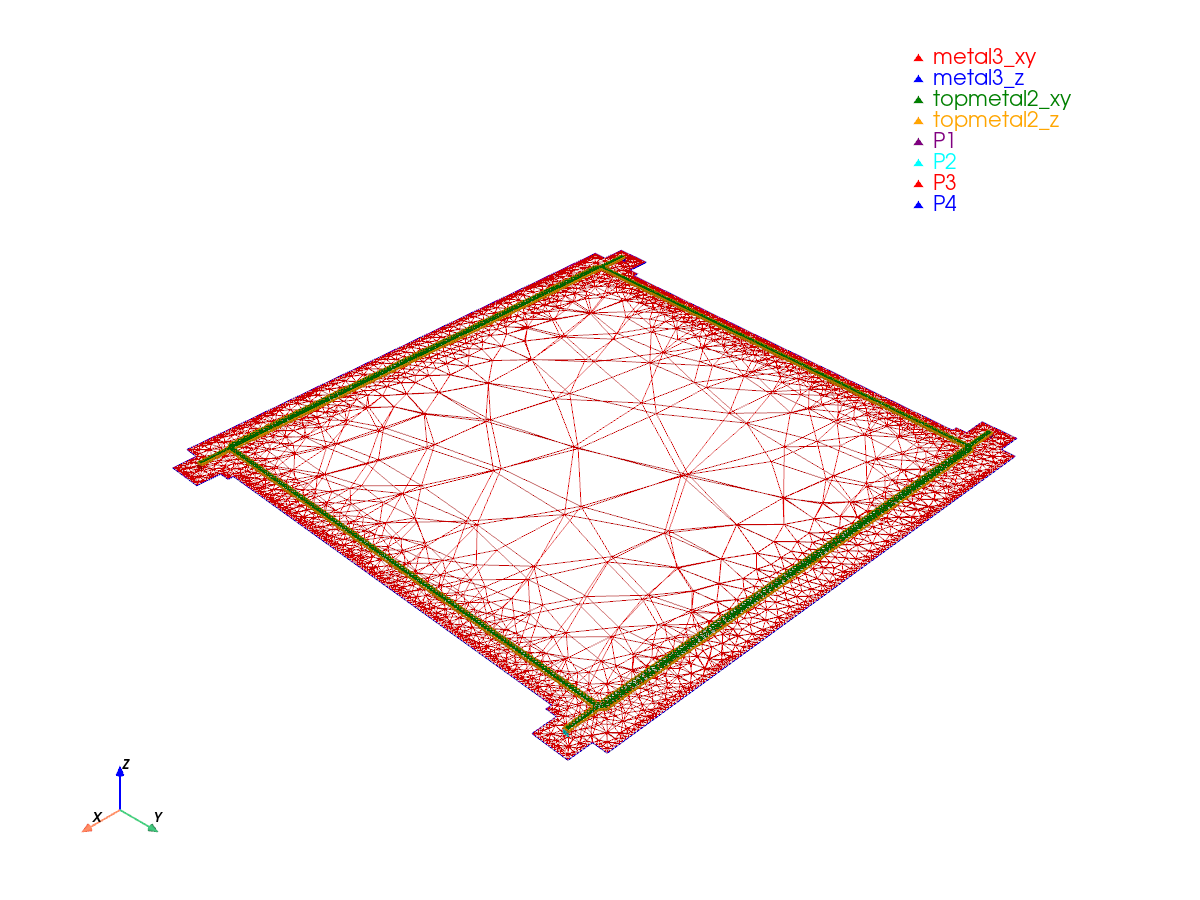

In [4]:
# Static PNG
sim.plot_mesh(show_groups=["metal", "P"])

### Run simulation on GDSFactory+ Cloud

In [5]:
# Run simulation on GDSFactory+ cloud
results = sim.run()

  palace-c3ce22ab  completed  43m 15s


Extracting results.tar.gz...
Downloaded 10 files to sim-data-palace-c3ce22ab


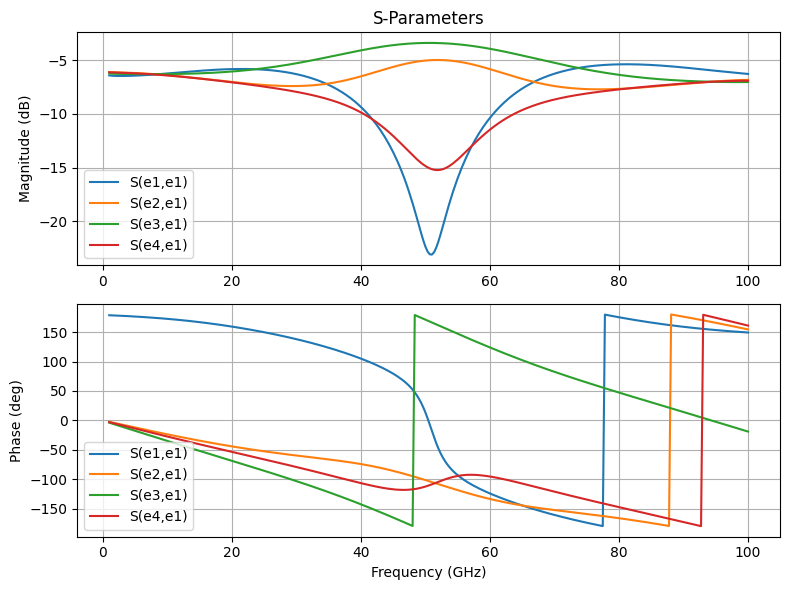

In [6]:
results.plot()